# Circular waveguide attenuation
The aim of this example is to reproduce the attenuation coefficients as presented in Balanis' Advanced Engineering Electromagnetics -- Third edition, Constantine A. Balanis, Wiley, 2024.

The 2 figures are shown on page 495.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import skrf as rf
from skrf.frequency import Frequency
from skrf.media import CircularWaveguide

rf.stylely()
# plot formatting
plt.rcParams['lines.linewidth'] = 1

In [2]:
sigma = 5.7e7

/home/antoine/git/scikit-rf/skrf/media/circularWaveguide.py:407: RuntimeWarning: divide by zero encountered in divide
  return Rs / r / z0 / np.sqrt(1 - (1 / f_n)**2) * ((1 / f_n)**2 + m**2 / (Jp**2 - m**2))
/home/antoine/git/scikit-rf/skrf/media/circularWaveguide.py:407: RuntimeWarning: invalid value encountered in sqrt
  return Rs / r / z0 / np.sqrt(1 - (1 / f_n)**2) * ((1 / f_n)**2 + m**2 / (Jp**2 - m**2))
/home/antoine/git/scikit-rf/skrf/media/circularWaveguide.py:404: RuntimeWarning: divide by zero encountered in divide
  return Rs / r / z0 / np.sqrt(1 - (1 / f_n)**2)
/home/antoine/git/scikit-rf/skrf/media/circularWaveguide.py:404: RuntimeWarning: invalid value encountered in sqrt
  return Rs / r / z0 / np.sqrt(1 - (1 / f_n)**2)


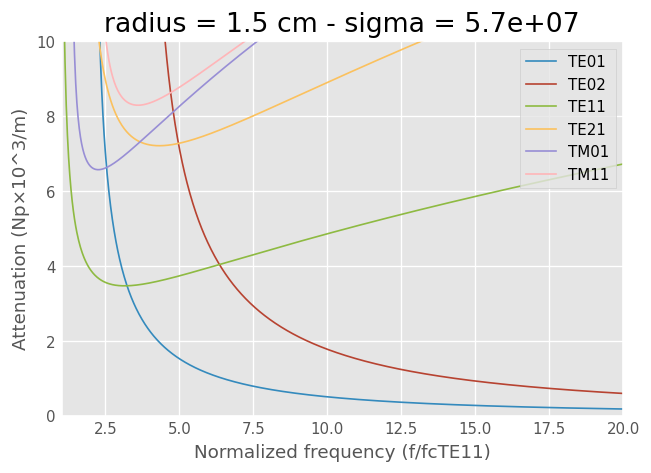

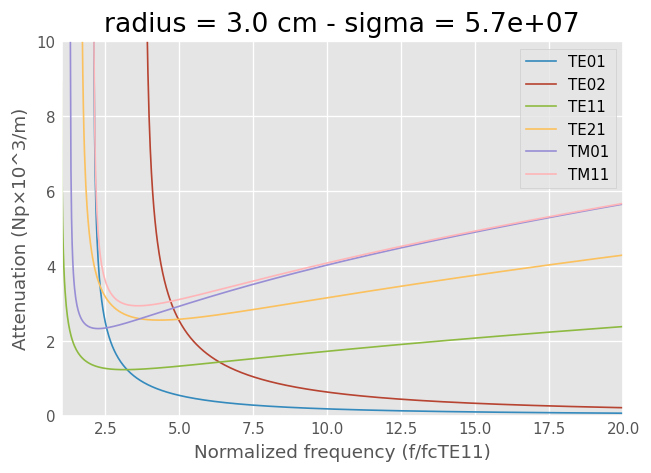

In [3]:
for radius in [1.5e-2, 3e-2]:
    test = CircularWaveguide(r=radius, m=1, n=1)
    fcTE11 = test.f_cutoff
    fmax = fcTE11 * 20
    f = Frequency(0, fmax, 1001, 'Hz')

    te01 = CircularWaveguide(f.copy(), r=radius, m=0, n=1, rho=1/sigma, mode_type='te')
    te02 = CircularWaveguide(f.copy(), r=radius, m=0, n=2, rho=1/sigma, mode_type='te')
    te11 = CircularWaveguide(f.copy(), r=radius, m=1, n=1, rho=1/sigma, mode_type='te')
    te21 = CircularWaveguide(f.copy(), r=radius, m=2, n=1, rho=1/sigma, mode_type='te')
    tm01 = CircularWaveguide(f.copy(), r=radius, m=0, n=1, rho=1/sigma, mode_type='tm')
    tm11 = CircularWaveguide(f.copy(), r=radius, m=1, n=1, rho=1/sigma, mode_type='tm')
    te01.name = "TE01"
    te02.name = "TE02"
    te11.name = "TE11"
    te21.name = "TE21"
    tm01.name = "TM01"
    tm11.name = "TM11"

    mode_list = [te01, te02, te11, te21, tm01, tm11]

    fig, ax = plt.subplots()

    for mode in mode_list:
        plt.plot(mode.frequency.f/fcTE11, (mode.alpha)*1e3, label=mode.name)

    ax.set_ylim(0, 10)
    ax.legend(loc='upper right')
    ax.set_xlabel('Normalized frequency (f/fcTE11)')
    ax.set_ylabel('Attenuation (Np×10^3/m)')
    ax.set_title('radius = %.1f cm - sigma = %g' % (radius*1e2, sigma))